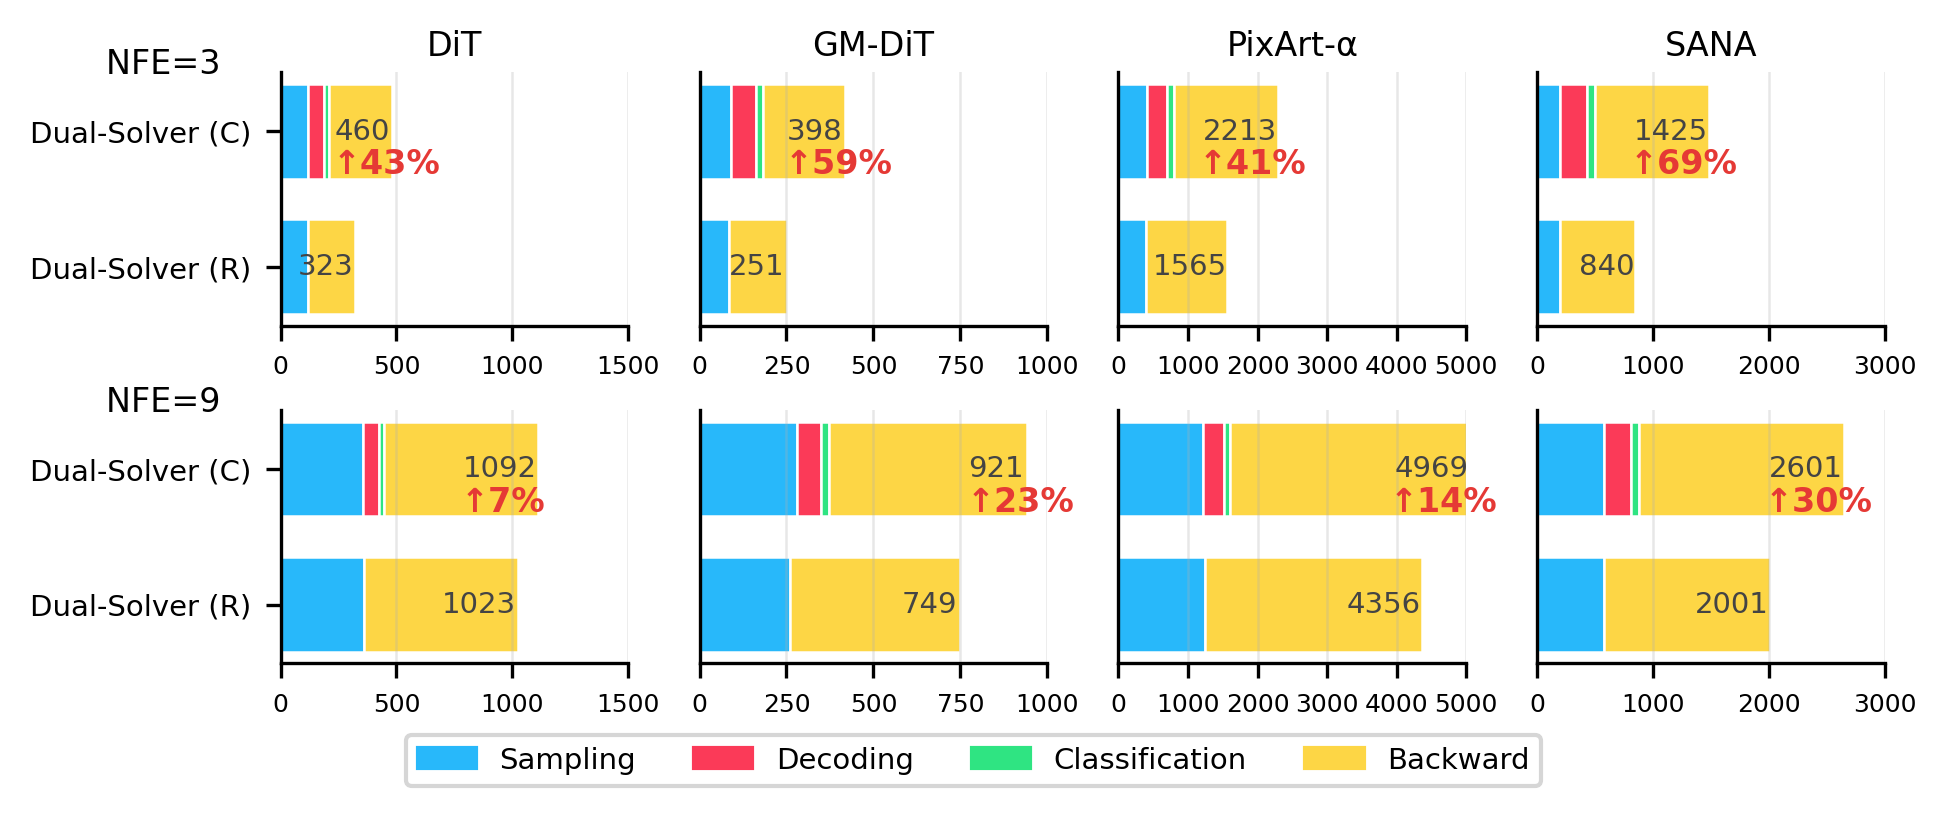

In [2]:
# Re-render with NFE row labels moved upward near the top of each row's y-axis area
import numpy as np
import matplotlib.pyplot as plt
import math

# Palette
PALETTES = {
    "journal_printsafe": {
        "Sampling":  "#28B8FA",
        "Decoding":  "#FB3A58",
        "Classification":"#2FE482",
        "Backward":  "#FDD645",
    },
}
palette = PALETTES["journal_printsafe"]

# Data
DATA = {
    "DiT": {
        3: {"Dual-Solver (C)": [119.48, 69.36, 1.50, 270.49], "Dual-Solver (R)": [120.14, 0.00, 0.00, 202.96]},
        9: {"Dual-Solver (C)": [356.95, 69.52, 1.50, 664.14], "Dual-Solver (R)": [358.33, 0.00, 0.00, 665.18]},
    },
    "GM-DiT": {
        3: {"Dual-Solver (C)": [90.81, 70.21, 1.50, 236.34], "Dual-Solver (R)": [85.65, 0.00, 0.00, 165.59]},
        9: {"Dual-Solver (C)": [279.75, 70.33, 1.50, 569.80], "Dual-Solver (R)": [259.57, 0.00, 0.00, 490.31]},
    },
    "PixArt-α": {
        3: {"Dual-Solver (C)": [404.42, 299.32, 15.02, 1495.07], "Dual-Solver (R)": [400.58, 0.00, 0.00, 1165.00]},
        9: {"Dual-Solver (C)": [1217.43, 298.51, 22.39, 3430.86], "Dual-Solver (R)": [1244.25, 0.00, 0.00, 3112.25]},
    },
    "SANA": {
        3: {"Dual-Solver (C)": [195.51, 232.74, 17.00, 980.08], "Dual-Solver (R)": [194.44, 0.00, 0.00, 646.53]},
        9: {"Dual-Solver (C)": [576.15, 232.98, 26.39, 1765.84], "Dual-Solver (R)": [571.57, 0.00, 0.00, 1430.41]},
    },
}

comps = ["Sampling", "Decoding", "Classification", "Backward"]
labels = ["Dual-Solver (C)", "Dual-Solver (R)"]
models = ["DiT", "GM-DiT", "PixArt-α", "SANA"]
MIN_RATIO = 0.3

# ============================
# % 라벨 오프셋 설정 (포인트 단위)
#   - dx: +면 오른쪽, -면 왼쪽
#   - dy: +면 아래,  -면 위   (va='top' 기준)
# ============================

# (1) 전체 큰 조정
PCT_GLOBAL_COARSE_PT = {"dx": 2, "dy": -4}

# (2) 전체 작은 조정
PCT_GLOBAL_FINE_PT   = {"dx": 0, "dy": 0}

# (3) 패널별 큰 조정: (row, col) -> {"dx": ..., "dy": ...}
#     row: 0 = NFE=3, 1 = NFE=9
#     col: 0=DiT, 1=GM-DiT, 2=PixArt-α, 3=SANA
PCT_PER_AX_COARSE_PT = {
    (0,0): {"dx": 10, "dy": 0},
    (0,1): {"dx": 10, "dy": 0},
    (0,2): {"dx": 5, "dy": 0},
    (0,3): {"dx": 5, "dy": 0},
    (1,0): {"dx": 0, "dy": 0},
    (1,1): {"dx": 10, "dy": 0},
    (1,2): {"dx": 5, "dy": 0},
    (1,3): {"dx": 5, "dy": 0},
}

# (4) 패널별 작은 조정(필요한 곳만 값 넣기; 없으면 0으로 처리)
PCT_PER_AX_FINE_PT = {
    # 예) (0,2): {"dx": 1, "dy": -1},
}

def get_pct_offsets_pt(pos):
    """pos=(row,col) 기준으로 전역/패널별 coarse+fine 합산 오프셋 반환"""
    dx = (
        PCT_GLOBAL_COARSE_PT.get("dx", 0)
        + PCT_GLOBAL_FINE_PT.get("dx", 0)
        + PCT_PER_AX_COARSE_PT.get(pos, {}).get("dx", 0)
        + PCT_PER_AX_FINE_PT.get(pos, {}).get("dx", 0)
    )
    dy = (
        PCT_GLOBAL_COARSE_PT.get("dy", 0)
        + PCT_GLOBAL_FINE_PT.get("dy", 0)
        + PCT_PER_AX_COARSE_PT.get(pos, {}).get("dy", 0)
        + PCT_PER_AX_FINE_PT.get(pos, {}).get("dy", 0)
    )
    return dx, dy

def _max_total_for_model(model):
    return max(sum(DATA[model][nfe][s]) for nfe in [3,9] for s in labels)

def compute_column_xlim(model):
    base_max = _max_total_for_model(model)
    step_guess = 250 if base_max <= 1000 else (500 if base_max <= 2000 else (1000 if base_max <= 5000 else 2000))
    upper = math.ceil(base_max / step_guess) * step_guess
    return (0, upper)

def draw_panel(ax, model, nfe, xlim, pos, *, row_spacing=0.40, bar_height=0.28):
    y = np.array([1, 0]) * row_spacing
    totals_true = {s: sum(DATA[model][nfe][s]) for s in labels}

    for idx, solver in enumerate(labels):
        left_plot = 0.0
        left_true = 0.0
        dec_w = DATA[model][nfe][solver][comps.index("Decoding")]

        for comp, w in zip(comps, DATA[model][nfe][solver]):
            if "(R)" in solver and comp in ("Decoding", "Classification"):
                left_true += w
                continue
            plot_w = max(w, dec_w * MIN_RATIO) if "(C)" in solver and comp == "Classification" else w
            if plot_w > 0:
                ax.barh(
                    y[idx], plot_w, height=bar_height, left=left_plot,
                    color=palette[comp], edgecolor="white", linewidth=0.6
                )
                left_plot += plot_w
            left_true += w

        # 총합(내림) 숫자
        tx = max(0, left_plot - 8.0)
        num_text = ax.text(
            tx, y[idx], f"{math.floor(left_true)}",
            va="center", ha="right", fontsize=7, color="#444444", clip_on=True
        )

        # (C) 퍼센트: 숫자 '바로 아래', 포인트 단위 오프셋(전역+패널별)
        if "(C)" in solver:
            denom = totals_true.get("Dual-Solver (R)", 0.0)
            if denom > 0:
                pct = int(round((totals_true["Dual-Solver (C)"] - denom) / denom * 100.0))
                x_num, y_num = num_text.get_position()
                dx_pt, dy_pt = get_pct_offsets_pt(pos)
                ax.annotate(
                    f"↑{pct:d}%",
                    xy=(x_num, y_num),
                    xytext=(dx_pt, dy_pt),   # dy>0 이면 아래로
                    textcoords="offset points",
                    ha="right", va="top",
                    fontsize=8, fontweight="bold",
                    color="#E53935",
                    annotation_clip=False,
                    zorder=10,
                )

    ax.set_yticks(y); ax.set_yticklabels(labels)
    ax.grid(axis="x", linestyle="-", linewidth=0.6, alpha=0.3)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.set_xlim(*xlim)

# Global style
plt.rcParams.update({
    "figure.dpi": 300,
    "font.size": 7,
    "axes.linewidth": 0.8,
    "mathtext.fontset": "cm",
    "xtick.labelsize": 6,
})

fig, axes = plt.subplots(2, 4, figsize=(6.5, 2.5), sharex=False)
axes = axes.reshape(2, 4)

xlims = {model: compute_column_xlim(model) for model in models}
for col, model in enumerate(models):
    xlim = xlims[model]
    # row=0 → NFE=3, row=1 → NFE=9
    draw_panel(axes[0, col], model, 3, xlim, pos=(0, col))
    draw_panel(axes[1, col], model, 9, xlim, pos=(1, col))
    _, xmax = xlim
    step = 250 if xmax <= 1000 else (500 if xmax <= 2000 else (1000 if xmax <= 5000 else 2000))
    axes[0, col].set_xticks(np.arange(0, xmax + 1e-9, step))
    axes[1, col].set_xticks(np.arange(0, xmax + 1e-9, step))

# 좌측 제외 Y틱/라벨 제거
for r in range(2):
    for c in range(1, 4):
        axes[r, c].set_yticklabels([])
        axes[r, c].set_yticks([])
        axes[r, c].tick_params(axis='y', length=0)

# 상단 타이틀만
for col, model in enumerate(models):
    axes[0, col].set_title(model, fontsize=8, pad=4)
    axes[1, col].set_title("")

plt.tight_layout()

# NFE 라벨(왼쪽, 각 행 상단 가까이)
p_top = axes[0,0].get_position(); p_bot = axes[1,0].get_position()
x_text = min(p_top.x0, p_bot.x0) - 0.02
offset_top = 0.10
offset_bot = 0.10
y_top = (p_top.y0 + p_top.y1) / 2.0 + 0.08 + offset_top
y_bot = (p_bot.y0 + p_bot.y1) / 2.0 + 0.08 + offset_bot
fig.text(x_text, y_top, "NFE=3  ", ha="right", va="center", fontsize=8)
fig.text(x_text, y_bot, "NFE=9  ", ha="right", va="center", fontsize=8)

# 범례
handles = [plt.Rectangle((0,0),1,1,color=palette[k]) for k in comps]
fig.legend(
    handles, comps, loc="lower center", ncol=4, frameon=True,
    fontsize=7, bbox_to_anchor=(0.5, -0.07)
)

plt.show()


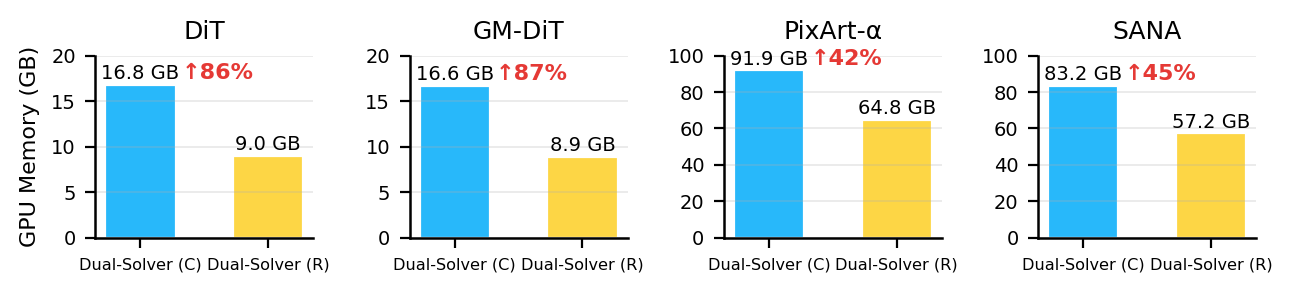

In [33]:
# GPU Memory (GB) vertical bar charts — NFE=3 only (with % increase next to C)
import numpy as np
import matplotlib.pyplot as plt
import math

# ==== Memory data in MB (from screenshots) ====
MEM_MB = {
    "DiT":      {3: {"C": 17153, "R":  9221}, 9: {"C": 17159, "R":  9227}},
    "GM-DiT":   {3: {"C": 17047, "R":  9115}, 9: {"C": 17055, "R":  9119}},
    "PixArt-α": {3: {"C": 94095, "R": 66319}, 9: {"C": 94123, "R": 66299}},
    "SANA":     {3: {"C": 85153, "R": 58587}, 9: {"C": 85167, "R": 58601}},
}

models   = ["DiT", "GM-DiT", "PixArt-α", "SANA"]
xlabels  = ["Dual-Solver (C)", "Dual-Solver (R)"]

# colors: (C)=#28B8FA, (R)=#FDD645
bar_cols = {"C": "#28B8FA", "R": "#FDD645"}

GB_BASE  = 1024.0
NFE_SHOW = 3

plt.rcParams.update({
    "figure.dpi": 200,
    "font.size": 8,
    "axes.linewidth": 0.9,
    "xtick.labelsize": 5.8,
    "ytick.labelsize": 7,
})

def mb_to_gb(mb): return mb / GB_BASE

def coarse_step_gb(upper_gb):
    if upper_gb <= 25:   return 5
    if upper_gb <= 80:   return 10
    if upper_gb <= 160:  return 20
    return 50

def compute_ylim_gb_for(model, nfe, pad_ratio=0.06):
    mx = max(mb_to_gb(MEM_MB[model][nfe]["C"]),
             mb_to_gb(MEM_MB[model][nfe]["R"]))
    upper = mx * (1 + pad_ratio)
    step  = coarse_step_gb(upper)
    upper = math.ceil(upper / step) * step
    return (0, upper, step)

def draw_panel(ax, model, nfe, ylim_gb, *, bar_width=0.55):
    # values in MB and GB
    c_mb = MEM_MB[model][nfe]["C"]; r_mb = MEM_MB[model][nfe]["R"]
    vals_gb = [mb_to_gb(c_mb), mb_to_gb(r_mb)]
    xs = np.arange(2)

    # bars
    bars = ax.bar(xs, vals_gb, width=bar_width,
                  color=[bar_cols["C"], bar_cols["R"]],
                  edgecolor="white", linewidth=0.8)

    # numeric labels on top (GB)
    for x, v in zip(xs, vals_gb):
        y_lab = v + ylim_gb[1]*0.01
        ax.text(x, y_lab, f"{v:.1f} GB",
                ha="center", va="bottom", fontsize=7)

    # ---- add % increase for C right next to the C label ----
    pct = int(round((c_mb - r_mb) / r_mb * 100.0))
    c_y_label = vals_gb[0] + ylim_gb[1]*0.01
    ax.annotate(
        f"↑{pct}%",
        xy=(xs[0]+0.15, c_y_label), xytext=(8, 0), textcoords="offset points",
        ha="left", va="bottom", fontsize=8, fontweight="bold",
        color="#E53935", annotation_clip=False, zorder=10
    )

    ax.set_xticks(xs); ax.set_xticklabels(xlabels)
    ax.set_ylim(*ylim_gb[:2])
    ax.set_yticks(np.arange(ylim_gb[0], ylim_gb[1] + 1e-9, ylim_gb[2]))
    ax.grid(axis="y", linestyle="-", linewidth=0.6, alpha=0.3)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

# ---- figure (1 x 4) ----
fig, axes = plt.subplots(1, 4, figsize=(6.5, 1.5), sharex=False, sharey=False)

for col, model in enumerate(models):
    ylim = compute_ylim_gb_for(model, NFE_SHOW)
    draw_panel(axes[col], model, NFE_SHOW, ylim)
    axes[col].set_title(model, fontsize=9, pad=6)

axes[0].set_ylabel("GPU Memory (GB)")

plt.tight_layout()
plt.show()
